# Auswertung Docking + Docking Score

In this script we will analyze the docking results obtained with Maestro. First we will read in the docking results

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ro5_not_fullfilled = pd.read_csv("/Users/lukas/Desktop/mol_mol_pr/Day_3/docking_my_protein/data_docking/ro5_not_fullfilled_docking_data.csv",sep=",")
ro5_fullfilled_split1 = pd.read_csv("/Users/lukas/Desktop/mol_mol_pr/Day_3/docking_my_protein/data_docking/ro5_fulllfilled_docking_data_split.csv",sep=",")
ro5_fullfilled_split2 = pd.read_csv("/Users/lukas/Desktop/mol_mol_pr/Day_3/docking_my_protein/data_docking/ro5_fulllfilled_docking_data.csv",sep=",")

print(ro5_not_fullfilled.shape)
print(ro5_fullfilled_split1.shape)
print(ro5_fullfilled_split2.shape)

# For ro5 not fullfilled delete first 677 rows
ro5_not_fullfilled = ro5_not_fullfilled.iloc[677:,:]


# For ro5 fulfilled split 1 delete first row

ro5_fullfilled_split1 = ro5_fullfilled_split1.iloc[1:,:]
#ro5_fullfilled_split1.head()

# For ro5 fulfilled split 2 delete first row
ro5_fullfilled_split2 = ro5_fullfilled_split2.iloc[1:,:]

#ro5_fullfilled_split2.head()

# Concatenate the two dataframes
ro5_fullfilled = pd.concat([ro5_fullfilled_split1, ro5_fullfilled_split2], axis=0)

ro5_not_fullfilled.head()

(3270, 353)
(1086, 366)
(4390, 366)


/var/folders/zl/tr4yyt811072b_l4prllbb4m0000gn/T/ipykernel_9552/1876210164.py:8: DtypeWarning: Columns (6,7,14,16,17,22,25,26,30,31,32,34,63,75,76,99,100) have mixed types. Specify dtype option on import or set low_memory=False.
  ro5_fullfilled_split2 = pd.read_csv("/Users/lukas/Desktop/mol_mol_pr/Day_3/docking_my_protein/data_docking/ro5_fulllfilled_docking_data.csv",sep=",")


,Stars,Title,Entry ID,Entry Name,Date Added,Date Modified,PDB TITLE,PDB ID,PDB CRYST1 a,PDB CRYST1 b,...,res:A125 vdw,res:A125 coul,res:A125 hbond,res:A125 dist,res:A125 Eint,res:A124 vdw,res:A124 coul,res:A124 hbond,res:A124 dist,res:A124 Eint
677,NaN,CHEMBL9238,736,CHEMBL9238_ro5_violated_without_pains.1,07 May 2025 17:01,07 May 2025 17:01,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
678,NaN,CHEMBL9238,737,CHEMBL9238_ro5_violated_without_pains.1,07 May 2025 17:01,07 May 2025 17:01,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
679,NaN,CHEMBL9263,738,CHEMBL9263_ro5_violated_without_pains.1,07 May 2025 17:01,07 May 2025 17:01,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
680,NaN,CHEMBL9263,739,CHEMBL9263_ro5_violated_without_pains.1,07 May 2025 17:01,07 May 2025 17:01,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
681,NaN,CHEMBL9295,740,CHEMBL9295_ro5_violated_without_pains.1,07 May 2025 17:01,07 May 2025 17:01,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# make a reduced dataframe with only the columns we need
columns = ["Title", "docking score", "glide ligand efficiency", "glide ligand efficiency ln", "glide gscore"]

ro5_not_fullfilled = ro5_not_fullfilled[columns]
ro5_fullfilled = ro5_fullfilled[columns]

# search if docking score entries that are not NaN
ro5_not_fullfilled = ro5_not_fullfilled[ro5_not_fullfilled["docking score"].notna()]
# Sort both dataframes via lowest docking score
ro5_not_fullfilled = ro5_not_fullfilled.sort_values(by=["docking score"], ascending=True)
ro5_fullfilled = ro5_fullfilled.sort_values(by=["docking score"], ascending=True)

ro5_not_fullfilled.head()


,Title,docking score,glide ligand efficiency,glide ligand efficiency ln,glide gscore
2066,CHEMBL475655,-10.443,-0.316,-2.322,-10.452
2067,CHEMBL460951,-10.255,-0.302,-2.266,-10.272
2068,CHEMBL1203953,-10.111,-0.281,-2.206,-10.123
2069,CHEMBL2203319,-10.060,-0.287,-2.208,-10.084
2070,CHEMBL5276657,-10.049,-0.287,-2.206,-10.056


In [4]:
# Calculate Mean and Standard deviation of docking score
mean_docking_score_not_fullfilled = ro5_not_fullfilled["docking score"].mean()
std_docking_score_not_fullfilled = ro5_not_fullfilled["docking score"].std()
mean_docking_score_fullfilled = ro5_fullfilled["docking score"].mean()
std_docking_score_fullfilled = ro5_fullfilled["docking score"].std()
print("Mean docking score not fullfilled: ", mean_docking_score_not_fullfilled)
print("Standard deviation docking score not fullfilled: ", std_docking_score_not_fullfilled)
print("Mean docking score fullfilled: ", mean_docking_score_fullfilled)
print("Standard deviation docking score fullfilled: ", std_docking_score_fullfilled)


Mean docking score not fullfilled:  -5.238356312292359
Standard deviation docking score not fullfilled:  2.274284597196607
Mean docking score fullfilled:  -5.539409937888199
Standard deviation docking score fullfilled:  2.152812733996925


In [5]:
# Calulate Number of entries with docking score less then -8
ro5_not_fullfilled_docking_score_less_8 = ro5_not_fullfilled[ro5_not_fullfilled["docking score"] < -8]
ro5_fullfilled_docking_score_less_8 = ro5_fullfilled[ro5_fullfilled["docking score"] < -8]
print("Number of entries with docking score less then -8 not fullfilled: ", ro5_not_fullfilled_docking_score_less_8.shape[0])
print("Number of entries with docking score less then -8 fullfilled: ", ro5_fullfilled_docking_score_less_8.shape[0])


Number of entries with docking score less then -8 not fullfilled:  144
Number of entries with docking score less then -8 fullfilled:  797


/var/folders/zl/tr4yyt811072b_l4prllbb4m0000gn/T/ipykernel_9552/6450206.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Title", y="docking score", data=ro5_not_fullfilled,
/var/folders/zl/tr4yyt811072b_l4prllbb4m0000gn/T/ipykernel_9552/6450206.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Title", y="docking score", data=ro5_fullfilled,


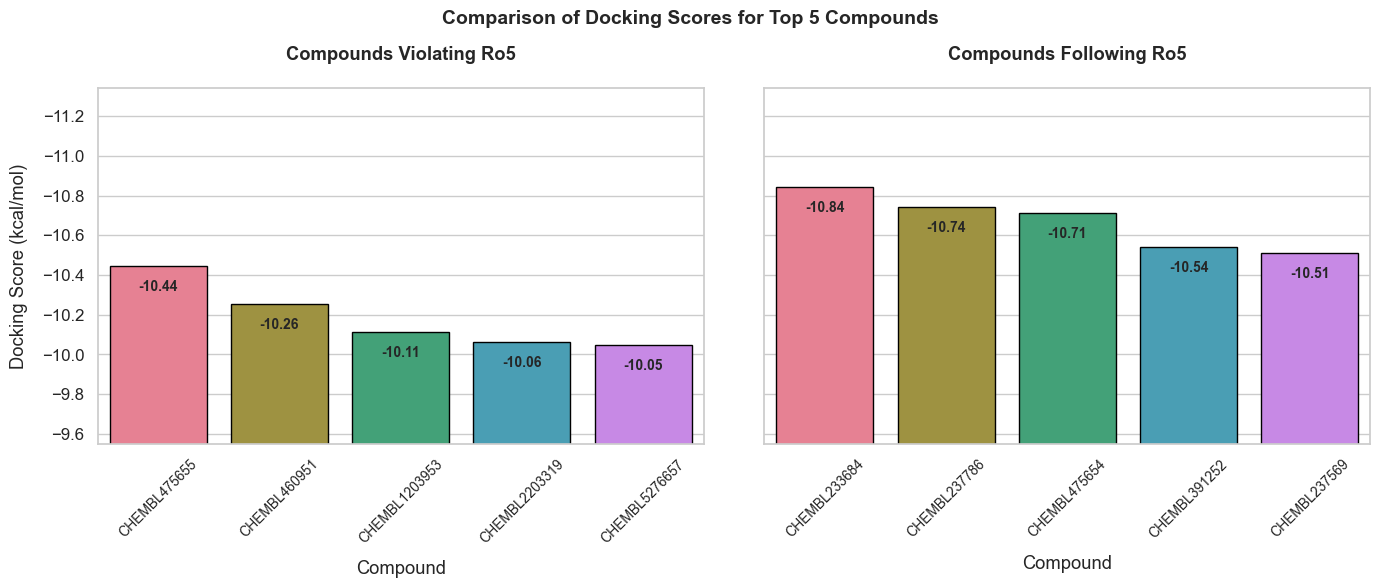

In [6]:
# Plot the Dockign Scores of the five best compounds
ro5_not_fullfilled = ro5_not_fullfilled.iloc[0:5,:]
ro5_fullfilled = ro5_fullfilled.iloc[0:5,:]

# Set style
sns.set(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.facecolor'] = 'white'

# Create figure
fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Define a consistent color palette
palette = sns.color_palette("husl", n_colors=5)

# Plot for compounds not fulfilling Ro5
sns.barplot(x="Title", y="docking score", data=ro5_not_fullfilled, 
            ax=ax[0], palette=palette, edgecolor='black', linewidth=1)
ax[0].set_title("Compounds Violating Ro5", pad=20, fontweight='bold')
ax[0].set_ylabel("Docking Score (kcal/mol)", labelpad=10)
ax[0].set_xlabel("Compound", labelpad=10)
ax[0].tick_params(axis='x', rotation=45, labelsize=10)
ax[0].invert_yaxis()  # Invert y-axis so higher scores appear better

# Plot for compounds fulfilling Ro5
sns.barplot(x="Title", y="docking score", data=ro5_fullfilled, 
            ax=ax[1], palette=palette, edgecolor='black', linewidth=1)
ax[1].set_title("Compounds Following Ro5", pad=20, fontweight='bold')
ax[1].set_ylabel("")  # Remove duplicate y-label
ax[1].set_xlabel("Compound", labelpad=10)
ax[1].tick_params(axis='x', rotation=45, labelsize=10)
ax[1].invert_yaxis()  # Invert y-axis so higher scores appear better

# Set consistent y-limits based on both datasets
combined_scores = pd.concat([ro5_not_fullfilled['docking score'], 
                            ro5_fullfilled['docking score']])
y_min = min(combined_scores) - 0.5
y_max = max(combined_scores) + 0.5
ax[0].set_ylim(y_max, y_min)  # Note: inverted because we inverted y-axis

# Add value labels on top of bars
for a in ax:
    for p in a.patches:
        a.annotate(f"{p.get_height():.2f}", 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha='center', va='center', 
                   xytext=(0, -15), textcoords='offset points',
                   fontsize=10, fontweight='bold')

# Adjust layout and add super title
plt.tight_layout()
plt.subplots_adjust(top=0.85, wspace=0.1)
fig.suptitle("Comparison of Docking Scores for Top 5 Compounds", 
             y=0.98, fontsize=14, fontweight='bold')

plt.show()

      Unnamed: 0 molecule_chembl_id units    IC50  \
1356        1356      CHEMBL1203953    nM    0.18   
1556        1556       CHEMBL460951    nM  770.00   
1748        1748       CHEMBL475655    nM   67.00   
2693        2693      CHEMBL2203319    nM   12.00   
3751        3751      CHEMBL5276657    nM    0.87   

                                       canonical_smiles     pIC50  \
1356  Cl.N[C@@H](CC(=O)N1CCn2c(nnc2C(F)(F)F)[C@H]1Cc...  8.744727   
1556  CCOC(=O)c1ccc(NC(=O)C2CC=NN2C(=O)C[C@H](N)Cc2c...  5.113509   
1748  Cl.N[C@@H](CC(=O)N1CCCN(C(=O)c2cncc(C(=O)O)c2)...  6.173925   
2693  N[C@@H](CC(=O)NC1(c2cccc(-n3ccnc3)c2)CCS(=O)(=...  6.920819   
3751  N[C@@H](CC(=O)N1CCC[C@H]1CNC(=O)c1cccc(S(N)(=O...  8.060481   

                                                  mols  
1356  <rdkit.Chem.rdchem.Mol object at 0x7f870f9528f0>  
1556  <rdkit.Chem.rdchem.Mol object at 0x7f870f958190>  
1748  <rdkit.Chem.rdchem.Mol object at 0x7f870f95d620>  
2693  <rdkit.Chem.rdchem.Mol object at

/var/folders/zl/tr4yyt811072b_l4prllbb4m0000gn/T/ipykernel_9552/4089464484.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Title", y="docking score", data=ro5_not_fullfilled,
/var/folders/zl/tr4yyt811072b_l4prllbb4m0000gn/T/ipykernel_9552/4089464484.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Title", y="docking score", data=ro5_fullfilled,
/var/folders/zl/tr4yyt811072b_l4prllbb4m0000gn/T/ipykernel_9552/4089464484.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="molecule_chembl_id", y="pIC50", data=ro5_not_fullfille

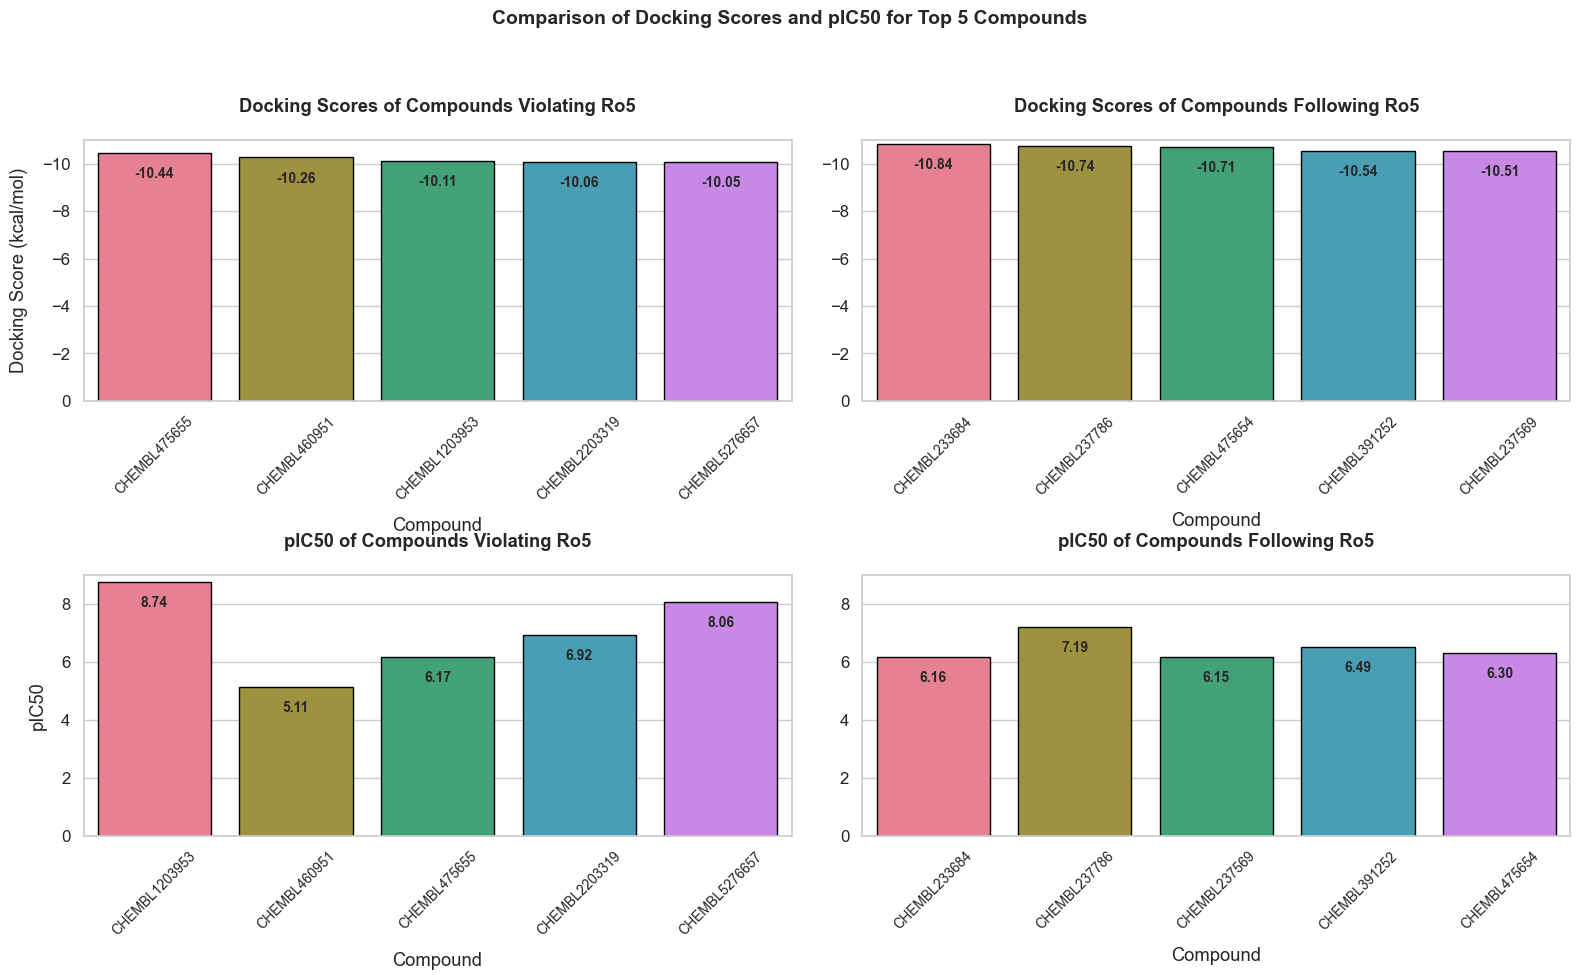

In [27]:
bioactivity_data = pd.read_csv("/Users/lukas/Desktop/mol_mol_pr/Day_4/bioactivity_and_smiles.csv", sep="\t")


# Search for top best five compounds of fullfilled and not fullfilled
ro5_not_fullfilled = ro5_not_fullfilled.iloc[0:5,:]
ro5_fullfilled = ro5_fullfilled.iloc[0:5,:]

# Obtain pIC50 out of bioactivity data
ro5_not_fullfilled_bioactivity = bioactivity_data[bioactivity_data["molecule_chembl_id"].isin(ro5_not_fullfilled["Title"])]
ro5_fullfilled_bioactivity = bioactivity_data[bioactivity_data["molecule_chembl_id"].isin(ro5_fullfilled["Title"])]
print(ro5_not_fullfilled_bioactivity.head())
# Make 4 Subplots , Docking Scores Of Violated and Following Ro5 in Top and pIC50 of Violated and Following Ro5 in Bottom


fig, ax = plt.subplots(2, 2, figsize=(16, 10), sharey=False)  # Changed to sharey=False for independent scaling
# Set style
sns.set(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.facecolor'] = 'white'
# Define a consistent color palette
palette = sns.color_palette("husl", n_colors=5)

# Plot for compounds not fulfilling Ro5 (Docking Scores)
sns.barplot(x="Title", y="docking score", data=ro5_not_fullfilled, 
            ax=ax[0, 0], palette=palette, edgecolor='black', linewidth=1)
ax[0, 0].set_title("Docking Scores of Compounds Violating Ro5", pad=20, fontweight='bold')
ax[0, 0].set_ylabel("Docking Score (kcal/mol)", labelpad=10)
ax[0, 0].set_xlabel("Compound", labelpad=10)
ax[0, 0].tick_params(axis='x', rotation=45, labelsize=10)
ax[0, 0].invert_yaxis()  # Invert y-axis so higher scores appear better
ax[0, 0].set_ylim(0, -11)  # Set y-axis limits from 0 to -11 (inverted)

# Plot for compounds fulfilling Ro5 (Docking Scores)
sns.barplot(x="Title", y="docking score", data=ro5_fullfilled, 
            ax=ax[0, 1], palette=palette, edgecolor='black', linewidth=1)
ax[0, 1].set_title("Docking Scores of Compounds Following Ro5", pad=20, fontweight='bold')
ax[0, 1].set_ylabel("")  # Remove duplicate y-label
ax[0, 1].set_xlabel("Compound", labelpad=10)
ax[0, 1].tick_params(axis='x', rotation=45, labelsize=10)
ax[0, 1].invert_yaxis()  # Invert y-axis so higher scores appear better
ax[0, 1].set_ylim(0, -11)  # Set y-axis limits from 0 to -11 (inverted)

# Plot for pIC50 of compounds not fulfilling Ro5
sns.barplot(x="molecule_chembl_id", y="pIC50", data=ro5_not_fullfilled_bioactivity, 
            ax=ax[1, 0], palette=palette, edgecolor='black', linewidth=1)
ax[1, 0].set_title("pIC50 of Compounds Violating Ro5", pad=20, fontweight='bold')
ax[1, 0].set_ylabel("pIC50", labelpad=10)
ax[1, 0].set_xlabel("Compound", labelpad=10)
ax[1, 0].tick_params(axis='x', rotation=45, labelsize=10)
ax[1, 0].set_ylim(0, 9)  # Set y-axis limits from 0 to 9

# Plot for pIC50 of compounds fulfilling Ro5
sns.barplot(x="molecule_chembl_id", y="pIC50", data=ro5_fullfilled_bioactivity, 
            ax=ax[1, 1], palette=palette, edgecolor='black', linewidth=1)
ax[1, 1].set_title("pIC50 of Compounds Following Ro5", pad=20, fontweight='bold')
ax[1, 1].set_ylabel("")  # Remove duplicate y-label
ax[1, 1].set_xlabel("Compound", labelpad=10)
ax[1, 1].tick_params(axis='x', rotation=45, labelsize=10)
ax[1, 1].set_ylim(0, 9)  # Set y-axis limits from 0 to 9


# Add value labels on top of bars for docking scores
for a in ax[0]:
    for p in a.patches:
        a.annotate(f"{p.get_height():.2f}", 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha='center', va='center', 
                   xytext=(0, -15), textcoords='offset points',
                   fontsize=10, fontweight='bold')
        
# Add value labels on top of bars for pIC50
for a in ax[1]:
    for p in a.patches:
        a.annotate(f"{p.get_height():.2f}", 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha='center', va='center', 
                   xytext=(0, -15), textcoords='offset points',
                   fontsize=10, fontweight='bold')

# Adjust layout and add super title
plt.tight_layout()
plt.subplots_adjust(top=0.85, wspace=0.1)
fig.suptitle("Comparison of Docking Scores and pIC50 for Top 5 Compounds", 
             y=0.98, fontsize=14, fontweight='bold')
plt.show()

